In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [7]:
# Load dataset
from google.colab import files
uploaded = files.upload()

Saving archive (2).zip to archive (2) (1).zip


In [8]:
import os
print(os.listdir())

['.config', 'archive (2) (1).zip', 'archive (2).zip', 'sample_data']


In [9]:
import zipfile

with zipfile.ZipFile("archive (2).zip", "r") as zip_ref:
    zip_ref.extractall("my_data")

In [10]:
import os
print(os.listdir("my_data"))

['car data.csv']


In [11]:
import pandas as pd

df = pd.read_csv("my_data/car data.csv")
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [12]:
# Feature Engineering
# Car age create
df["Car_Age"] = 2026 - df["Year"]
df.drop("Year", axis=1, inplace=True)

In [13]:
# Encode Categorical Data
le = LabelEncoder()

df["Fuel_Type"] = le.fit_transform(df["Fuel_Type"])
df["Selling_type"] = le.fit_transform(df["Selling_type"])
df["Transmission"] = le.fit_transform(df["Transmission"])
df["Car_Name"] = le.fit_transform(df["Car_Name"])

In [14]:
# Define Features and Target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [15]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
# Train Model
model = RandomForestRegressor()
model.fit(X_train, y_train)

RandomForestRegressor()

In [17]:
# Prediction
pred = model.predict(X_test)
print(pred[:5])

[ 0.4454 10.2518  4.971   0.2153  8.0652]


In [18]:
# Model Evaluation
mae = mean_absolute_error(y_test, pred)
mse = mean_squared_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("MAE:", mae)
print("MSE:", mse)
print("R2 Score:", r2)

MAE: 0.6578836065573774
MSE: 1.0201435201639355
R2 Score: 0.9557144504292752


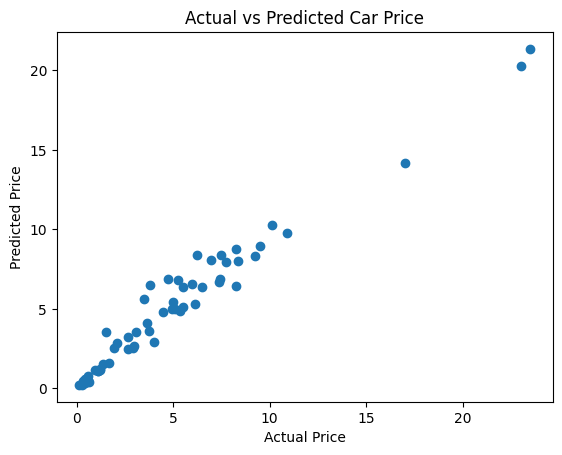

In [19]:
# Visualization
plt.scatter(y_test, pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Price")
plt.show()

In [ ]:
# project Objectives – Car Price Prediction using Machine Learning


# 1. To collect and analyze car-related features such as brand value, engine power (horsepower), mileage, fuel type, transmission, and ownership history that influence car prices.
# 2. To build and train a regression-based machine learning model capable of predicting the selling price of a car based on selected input features.
# 3. To perform data preprocessing and feature engineering, including handling missing values, encoding categorical variables, and creating useful derived features to improve model performance.
# 4. To evaluate model performance using suitable evaluation metrics such as Mean Absolute Error (MAE), Mean Squared Error (MSE), and R² Score.
# 5. To implement the complete workflow using Python libraries such as Pandas for data manipulation, Scikit-learn for machine learning, and Matplotlib for visualization.
# 6. To understand real-world applications of machine learning in automobile price estimation, helping buyers, sellers, and dealers make better pricing decisions.